# EDA — Demand Forecasting Dataset

Eksploracja danych przed budową modelu prognozy. Agregacja z `src/data.py`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw, aggregate_daily, train_val_split

plt.style.use("seaborn-v0_8-whitegrid")
FIGS = Path("outputs/figures"); FIGS.mkdir(parents=True, exist_ok=True)
raw = load_raw()
daily = aggregate_daily(raw)
train, val = train_val_split(daily)
print(f"Surowe: {len(raw):,} wierszy | Szereg: {len(daily)} dni | "
      f"trening {len(train)} dni / walidacja {len(val)} dni")

Surowe: 76,000 wierszy | Szereg: 760 dni | trening 732 dni / walidacja 28 dni


## 1. Szereg dzienny: sprzedaż vs popyt

`units` (sprzedaż) jest cenzurowana zapasem — `demand` pokazuje popyt.
Cienie = dni z epidemią (Epidemic=1).

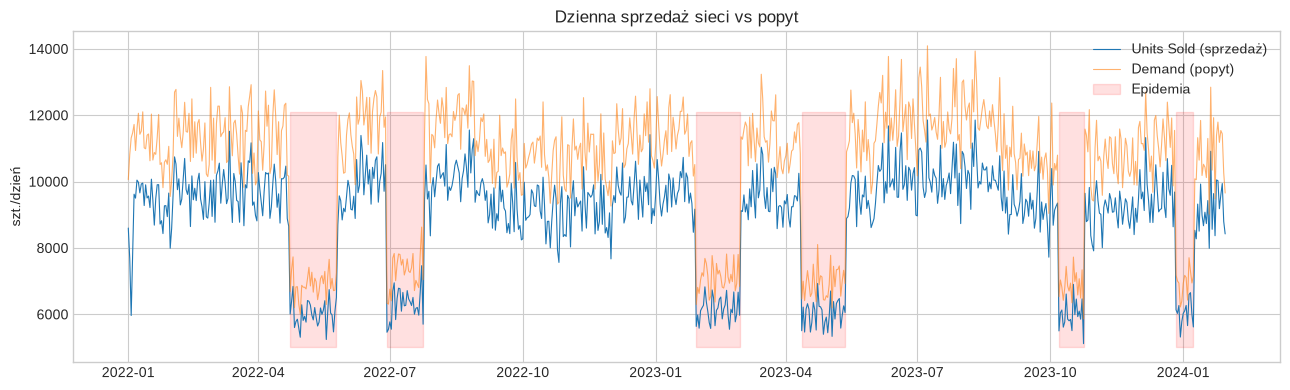

In [2]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily["units"], lw=.8, color="#1f77b4", label="Units Sold (sprzedaż)")
ax.plot(daily.index, daily["demand"], lw=.8, alpha=.6, color="#ff7f0e", label="Demand (popyt)")
ax.fill_between(daily.index, daily["units"].min()*0.98, daily["units"].max()*1.02,
                where=daily["epidemic"] == 1, color="red", alpha=.12, label="Epidemia")
ax.legend(loc="upper right"); ax.set_ylabel("szt./dzień")
ax.set_title("Dzienna sprzedaż sieci vs popyt")
fig.tight_layout(); fig.savefig(FIGS / "01_series.png", dpi=110)
plt.show()

## 2. Utracona sprzedaż (demand − units) a zapas

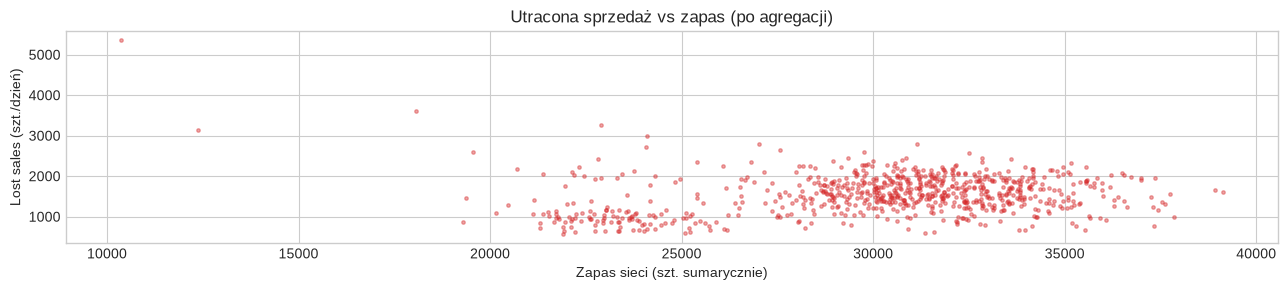

Korelacja (agregat): 0.167 | na poziomie wiersza: -0.166


In [3]:
daily["lost_sales"] = daily["demand"] - daily["units"]
fig, ax = plt.subplots(figsize=(13, 3))
ax.scatter(daily["inventory"], daily["lost_sales"], s=6, alpha=.4, color="#d62728")
ax.set_xlabel("Zapas sieci (szt. sumarycznie)"); ax.set_ylabel("Lost sales (szt./dzień)")
ax.set_title("Utracona sprzedaż vs zapas (po agregacji)")
fig.tight_layout(); fig.savefig(FIGS / "02_lost_sales.png", dpi=110)
plt.show()
print("Korelacja (agregat):", round(daily["lost_sales"].corr(daily["inventory"]), 3),
      "| na poziomie wiersza:", round((raw["Demand"]-raw["Units Sold"]).corr(raw["Inventory Level"]), 3))

## 3. Sezonowość: dzień tygodnia i miesiące

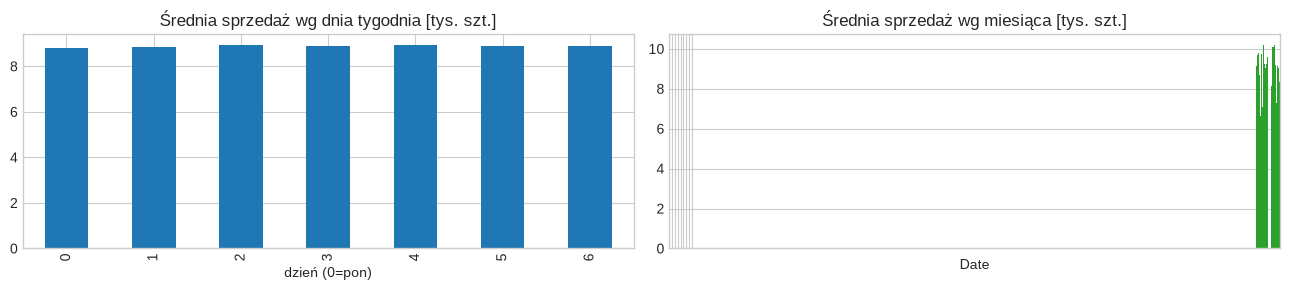

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
(daily.groupby(daily.index.dayofweek)["units"].mean()/1000).plot.bar(ax=axes[0], color="#1f77b4")
axes[0].set_title("Średnia sprzedaż wg dnia tygodnia [tys. szt.]"); axes[0].set_xlabel("dzień (0=pon)")
(daily["units"].resample("ME").mean()/1000).plot.bar(ax=axes[1], color="#2ca02c", width=.8)
axes[1].set_title("Średnia sprzedaż wg miesiąca [tys. szt.]")
axes[1].set_xticks(range(0, len(axes[1].get_xticklabels()), 3))
fig.tight_layout(); fig.savefig(FIGS / "03_seasonality.png", dpi=110)
plt.show()

## 4. Czynniki zewnętrzne: korelacje z sprzedażą

Pogoda i pora roku przypisane per dzień (dominanta), pozostałe cechy agregowane w `aggregate_daily`.

                  corr_z_units
price                    0.916
competitor_price         0.905
epidemic                -0.898
inventory                0.587
s_Summer                 0.251
s_Spring                -0.195
discount                 0.187
promotion                0.179
w_Sunny                  0.155
w_Snowy                 -0.093
w_Rainy                 -0.079
s_Winter                -0.042
s_Autumn                -0.013
w_Cloudy                 0.003


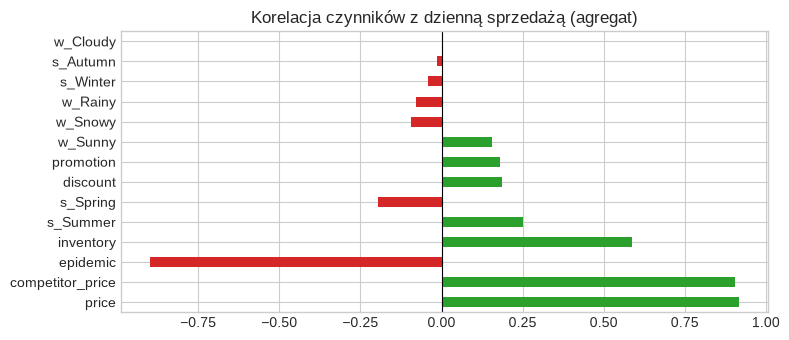

In [5]:
weather = raw.groupby("Date")["Weather Condition"].agg(lambda s: s.mode()[0])
season = raw.groupby("Date")["Seasonality"].agg(lambda s: s.mode()[0])
X = pd.concat([daily[["units","epidemic","promotion","discount","price","competitor_price","inventory"]],
               pd.get_dummies(weather, prefix="w").astype(float),
               pd.get_dummies(season, prefix="s").astype(float)], axis=1)
corr = X.corr()["units"].drop("units").sort_values(key=abs, ascending=False)
print(corr.round(3).to_frame("corr_z_units").to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#2ca02c", "#d62728"))
ax.axvline(0, c="k", lw=.8); ax.set_title("Korelacja czynników z dzienną sprzedażą (agregat)")
fig.tight_layout(); fig.savefig(FIGS / "04_factors.png", dpi=110)
plt.show()

## 5. Efekt grupowy: Epidemic / Promotion / Seasonality / Weather

In [6]:
print("Epidemic:  brak =", round(daily[daily.epidemic == 0]["units"].mean(), 0),
      "| epidemia =", round(daily[daily.epidemic == 1]["units"].mean(), 0))
promo = daily.groupby("promotion")["units"].mean()
print("Promotion (udział dnia 0/1):", {k: round(v) for k, v in promo.items()})
season_avg = X.groupby(X[["s_Spring","s_Summer","s_Autumn","s_Winter"]].idxmax(axis=1))["units"].mean()
weather_avg = X.groupby(X[["w_Sunny","w_Cloudy","w_Rainy","w_Snowy"]].idxmax(axis=1))["units"].mean()
print("Pora roku:", season_avg.round(0).to_dict())
print("Pogoda:   ", weather_avg.round(0).to_dict())

Epidemic:  brak = 9582.0 | epidemia = 6086.0
Promotion (udział dnia 0/1): {0.0: 8295, 0.1: 8096, 0.15: 8491, 0.2: 8642, 0.25: 8459, 0.3: 9005, 0.35: 8884, 0.4: 9088, 0.45: 9122, 0.5: 9477, 0.55: 8966, 0.6: 9013, 0.65: 10926, 0.7: 9621}
Pora roku: {'s_Autumn': 8846.0, 's_Spring': 8346.0, 's_Summer': 9576.0, 's_Winter': 8777.0}
Pogoda:    {'w_Cloudy': 8889.0, 'w_Rainy': 8659.0, 'w_Snowy': 8522.0, 'w_Sunny': 9346.0}


## 5b. Udziały produktów i kategorii w sprzedaży — czy przewidują SUMĘ?

Test hipotezy: czy mikstura (udział produktu/kategorii w dziennej sprzedaży)
pomaga prognozować łączną sprzedaż sieci.

In [7]:
cat = raw.pivot_table(index="Date", columns="Category", values="Units Sold", aggfunc="sum")
cat_share = cat.div(cat.sum(axis=1), axis=0)
prod = raw.pivot_table(index="Date", columns="Product ID", values="Units Sold", aggfunc="sum")
prod_share = prod.div(prod.sum(axis=1), axis=0)
top5 = prod.sum().nlargest(5).index.tolist()

print("Stabilność udziałów (CV = std/mean):")
print("  kategorie:", (cat_share.std() / cat_share.mean()).round(3).to_dict())
print("  top5 produkty:", (prod_share[top5].std() / prod_share[top5].mean()).round(3).to_dict())

print("KORELACJE udziałów z SUMĄ sprzedaży w przyszłości:")
for name, share in [("share_Electronics", cat_share["Electronics"]),
                    ("share_Groceries", cat_share["Groceries"]),
                    ("share_top1_prod", prod_share[top5[0]]),
                    ("share_top5_sum", prod_share[top5].sum(axis=1))]:
    print(f"  {name}: t+1 = {share.corr(tot_units := daily['units'].reindex(cat_share.index).shift(-1)):.3f}"
          f" | t+7 = {share.corr(daily['units'].reindex(cat_share.index).shift(-7)):.3f}")

# kluczowy test: czy udział wnosi cokolwiek ponad perzyystencję szeregu?
print("Benchmark: corr(units_t, units_t+1) =", round(daily['units'].corr(daily['units'].shift(-1)), 3))

def partial_corr(a, b, c):
    ra = np.corrcoef(a, c)[0,1]; rb = np.corrcoef(b, c)[0,1]; rab = np.corrcoef(a, b)[0,1]
    return (rab - ra*rb) / np.sqrt((1-ra**2)*(1-rb**2))

el = cat_share["Electronics"]
u = daily["units"].reindex(cat_share.index)
pc = partial_corr(el.values[:-1], u.values[:-1], u.shift(-1).values[:-1])
print("częściowa corr(share_Electronics_t, units_t+1 | units_t):", round(pc, 3))
print("→ wniosek: poza informacją z perzyystencji udział dodaje ~", round(pc**2*100, 1), "% wyjaśnionej wariancji")

Stabilność udziałów (CV = std/mean):
  kategorie: {'Clothing': 0.245, 'Electronics': 0.12, 'Furniture': 0.155, 'Groceries': 0.07, 'Toys': 0.255}
  top5 produkty: {'P0007': 0.217, 'P0004': 0.214, 'P0009': 0.226, 'P0013': 0.218, 'P0002': 0.207}
KORELACJE udziałów z SUMĄ sprzedaży w przyszłości:
  share_Electronics: t+1 = 0.275 | t+7 = 0.205
  share_Groceries: t+1 = -0.099 | t+7 = -0.021
  share_top1_prod: t+1 = 0.096 | t+7 = 0.057
  share_top5_sum: t+1 = -0.046 | t+7 = 0.000
Benchmark: corr(units_t, units_t+1) = 0.825
częściowa corr(share_Electronics_t, units_t+1 | units_t): 0.138
→ wniosek: poza informacją z perzyystencji udział dodaje ~ 1.9 % wyjaśnionej wariancji


**Wniosek:** udział produktów (korelacje ~0.05–0.10) i udział kategorii (marginalnie
Electronics ~0.14 częściowo, ~2% r²) nie przenoszą praktycznie żadnej informacji o
**poziomie** sumarycznej sprzedaży ponad to, co daje sama perzyystencja szeregu.
Udziały opisują *strukturę* koszyka, nie *poziom* sprzedaży — dlatego **nie** trafiają
do agregacji/modelu głównego (decyzja udokumentowana w README). Do modeli per produkt
(bonus) wraca za to `Category` jako cecha.



## 5c. Cykliczność sprzedaży per kategoria

Sprawdzenie: trendy, sezon roczny (średnie miesięczne) i autokorelacja (ACF) — czy kategorie mają własne cykle.

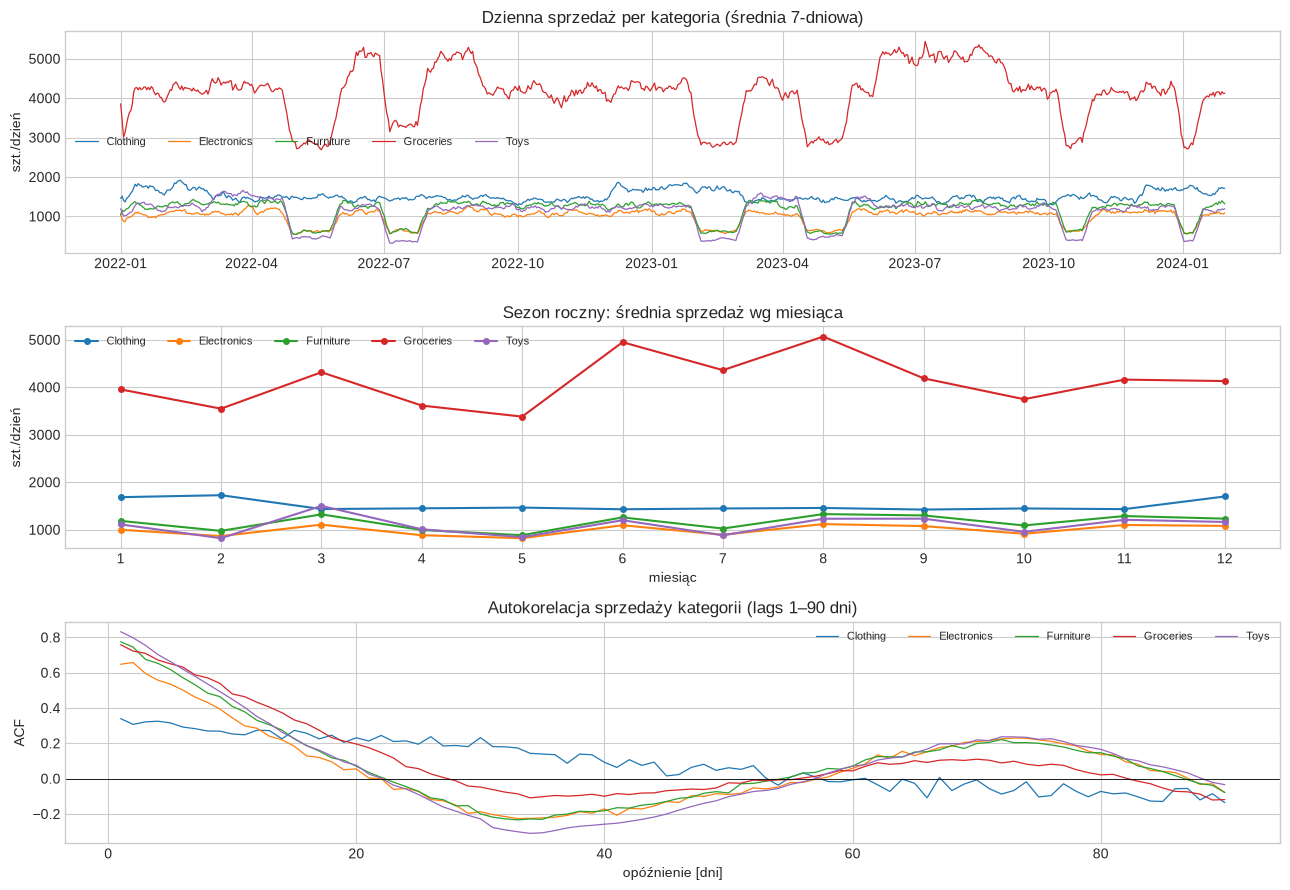

Amplituda sezonu rocznego (max/min średniej miesięcznej):
{'Clothing': 1.21, 'Electronics': 1.36, 'Furniture': 1.5, 'Groceries': 1.5, 'Toys': 1.83}
ACF przy wybranych lagach:
lag            1      7      14     30     60     90     365
Clothing     0.340  0.283  0.226  0.232 -0.007 -0.137  0.417
Electronics  0.648  0.462  0.220 -0.188  0.058 -0.079  0.075
Furniture    0.775  0.531  0.275 -0.200  0.070 -0.079  0.047
Groceries    0.758  0.588  0.373 -0.048  0.044 -0.119  0.265
Toys         0.832  0.580  0.263 -0.228  0.071 -0.034  0.087


In [8]:
cat_daily = raw.groupby(["Date", "Category"])["Units Sold"].sum().unstack()

fig, axes = plt.subplots(3, 1, figsize=(13, 9))

# 1) szereg dzienny (wygładzony 7d) per kategoria
for c in cat_daily.columns:
    axes[0].plot(cat_daily.index, cat_daily[c].rolling(7, min_periods=1).mean(), lw=.9, label=c)
axes[0].set_title("Dzienna sprzedaż per kategoria (średnia 7-dniowa)")
axes[0].set_ylabel("szt./dzień"); axes[0].legend(ncol=5, fontsize=8)

# 2) sezon roczny: średnia wg miesiąca
m = cat_daily.groupby(cat_daily.index.month).mean()
for c in m.columns:
    axes[1].plot(m.index, m[c], marker="o", ms=4, label=c)
axes[1].set_title("Sezon roczny: średnia sprzedaż wg miesiąca")
axes[1].set_xlabel("miesiąc"); axes[1].set_ylabel("szt./dzień")
axes[1].set_xticks(range(1, 13)); axes[1].legend(ncol=5, fontsize=8)

# 3) ACF per kategoria (lags 1..90)
lags = range(1, 91)
for c in cat_daily.columns:
    acf = [cat_daily[c].autocorr(lag) for lag in lags]
    axes[2].plot(lags, acf, lw=.9, label=c)
axes[2].set_title("Autokorelacja sprzedaży kategorii (lags 1–90 dni)")
axes[2].set_xlabel("opóźnienie [dni]"); axes[2].set_ylabel("ACF")
axes[2].axhline(0, c="k", lw=.6); axes[2].legend(ncol=5, fontsize=8)

fig.tight_layout(); fig.savefig(FIGS / "05_categories.png", dpi=110)
plt.show()

# kluczowe liczby
m_amp = (m.max() / m.min())
print("Amplituda sezonu rocznego (max/min średniej miesięcznej):")
print(m_amp.round(2).to_dict())
print("ACF przy wybranych lagach:")
sel = [1, 7, 14, 30, 60, 90, 365]
print(pd.DataFrame({c: [round(cat_daily[c].autocorr(l), 3) for l in sel] for c in cat_daily.columns},
                   index=sel).rename_axis("lag").T.to_string())

**Wnioski (cykliczność per kategoria):**
- **Sezon tygodniowy**: ACF@7 ≈ 0.28–0.59 — najsilniejszy w Groceries (0.59), Toys (0.58),
  Furniture (0.53); po agregacji sieciowej słabszy niż typowo (w zadaniu głównym prawie zerowy),
  ale **widoczny w kategoriach** — argument, by w bonusie per produkt używać sezonu tygodniowego.
- **Oscylacja ~60-dniowa**: ACF@30 ujemna, ACF@60 dodatnia (Furniture, Toys, Electronics) —
  cykl ~2 miesiące, prawdopodobnie artefakt generatora; nie opieramy na nim prognozy.
- **Sezon roczny**: amplituda średnich miesięcznych 1.2–1.8× (najwięcej Toys — szczyt grudniowy;
  Electronics wysokie latem). Lag 365 wyraźny tylko dla Clothing (0.42) — mamy zaledwie ~2 lata
  danych, więc sezon roczny potwierdzamy raczej przez średnie miesięczne niż ACF.
- **Perzyystencja**: ACF@1 = 0.34–0.83 (najwyższa Toys 0.83) — kategorie różnią się
  "pamięcią", co sugeruje różne parametry wygładzenia w modelach per produkt (bonus).


## 6. Wnioski i wybór czynników zewnętrznych

**Obserwacje:**
1. **Epidemic** — najsilniejszy czynnik (korelacja ~−0.9 na agregacie): dni z epidemią mają wyraźnie niższą sprzedaż. Zewnętrzny, niekontrolowany → **do modelu** (poza próbą: scenariusz "brak epidemii").
2. **Sezonowość roczna** — różnice między porami roku i miesiącami → **do modelu** (regresor pory roku lub sezonowość modelu).
3. **Price / Competitor Pricing** — wysokie korelacje (artefakt generatora danych); opisane zastrzeżenie: korelacja ≠ przyczynowość.
4. **Promotion / Discount** — słabe na agregacie (udział dnia); efekt rozmyty przez sumowanie po produktach → opisane w README.
5. **Weather** — słaby efekt (~0.1) po agregacji → pominięty w głównym modelu.
6. **Lost sales (demand − units)** — silny sygnał stockoutu na poziomie wiersza; po agregacji słabnie → kandydat na lag w modelach per produkt (bonus), nie w głównym szeregu.

**Decyzja (do README):** model główny: `Epidemic` + sezonowość roczna; `price`/`competitor_price` jako kontekst. Baseline: średnia ruchoma.
